# Random Forest Classifier - Student Graduate vs Dropout Prediction
**Objective:** Predict whether a student will graduate or drop out based on their academic and demographic background.

### 1. Importing Libraries
Loading the necessary tools for data manipulation, machine learning, and visualization.

In [1]:
# Importing required libraries for the project
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    matthews_corrcoef, confusion_matrix, ConfusionMatrixDisplay
)
import joblib
import warnings

# Suppress future warnings from seaborn
warnings.filterwarnings('ignore')

### 2. Data Preprocessing
Loading the dataset and removing 'Enrolled' students so we can strictly focus on a binary classification (Graduate vs. Dropout).

In [2]:
# 1. Load the dataset (separated by semicolons)
df = pd.read_csv('data.csv', delimiter=';')

# 2. Data Preprocessing
print("Null values count:", df.isnull().sum().sum(), "\n")

# Removing 'Enrolled' students to strictly classify Graduate vs Dropout
df = df[df['Target'] != 'Enrolled']

Null values count: 0 



### 3. Target Distribution
Visualizing the balance between Graduates and Dropouts in our cleaned dataset.

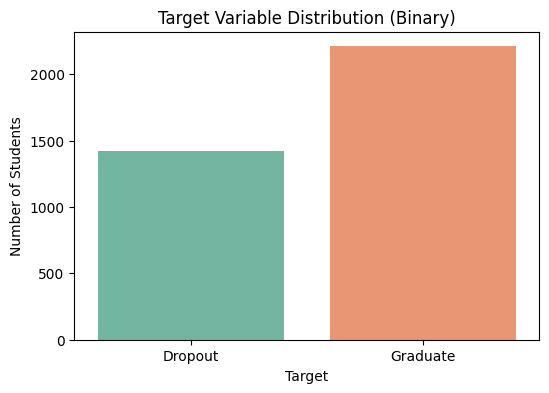

In [3]:
# Plotting the target distribution to visualize the class balance
plt.figure(figsize=(6, 4))
sns.countplot(x='Target', data=df, palette='Set2', hue='Target', legend=False)
plt.title('Target Variable Distribution (Binary)')
plt.ylabel('Number of Students')
plt.show()

# Setting up features (X) and target (y)
X = df.drop('Target', axis=1)
y = df['Target']

### 4. Data Splitting and Model Training
Splitting the data into 80% training and 20% testing sets using stratification, then training a Random Forest with 100 decision trees.

In [4]:
# 3. Data Splitting
# 80-20 train-test split using stratify to maintain class proportions
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Model Initialization and Training
# Creating the random forest classifier with 100 trees
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

### 5. Prediction and Evaluation
Generating predictions on our test set and evaluating the model using Accuracy, MCC (Matthews Correlation Coefficient), and a Confusion Matrix.

          RANDOM FOREST TEST RESULTS
  Test Accuracy:      0.9146  (91.46%)
  MCC Score:          0.8215
Classification Report:
              precision    recall  f1-score   support

     Dropout       0.95      0.82      0.88       284
    Graduate       0.90      0.97      0.93       442

    accuracy                           0.91       726
   macro avg       0.92      0.90      0.91       726
weighted avg       0.92      0.91      0.91       726



<Figure size 600x500 with 0 Axes>

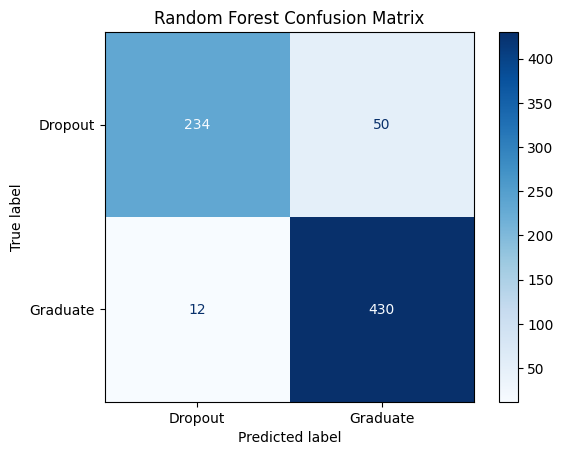

In [5]:
# 5. Prediction and Evaluation
predictions = rf_model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)
mcc = matthews_corrcoef(y_test, predictions)

print("=" * 48)
print("          RANDOM FOREST TEST RESULTS")
print("=" * 48)
print(f"  Test Accuracy:      {accuracy:.4f}  ({accuracy * 100:.2f}%)")
print(f"  MCC Score:          {mcc:.4f}")
print("=" * 48)
print("Classification Report:")
print(classification_report(y_test, predictions))

# --- NEW: Confusion Matrix Visualization ---
cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(6, 5))
# Dynamically getting the class labels used by the model
labels = rf_model.classes_
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='Blues', values_format='d')
plt.title('Random Forest Confusion Matrix')
plt.show()

### 6. Feature Importance Visualization
Extracting the top 10 most influential factors that determine if a student drops out or graduates.

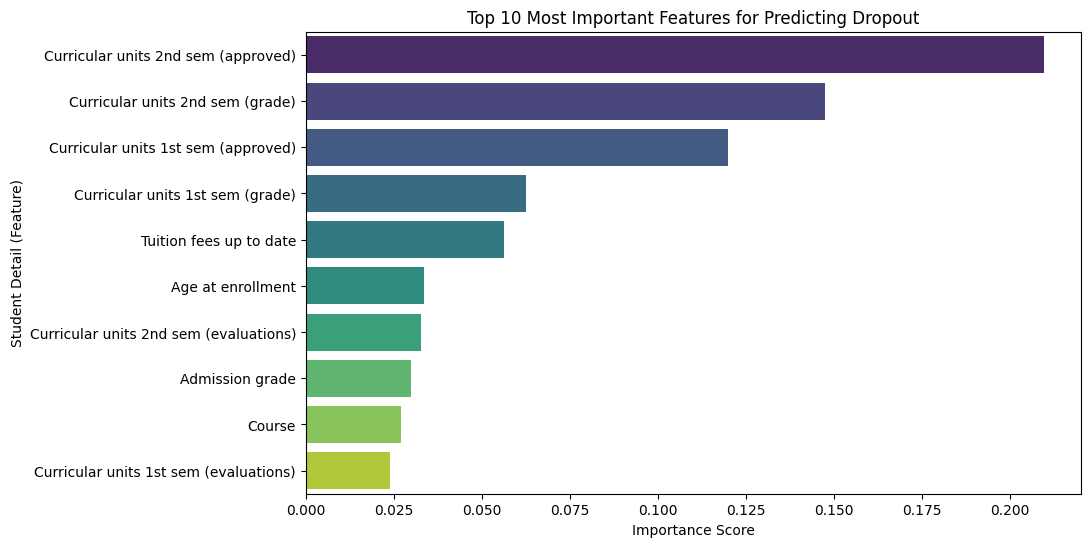

In [6]:
# 6. Feature Importance Visualization
importances = rf_model.feature_importances_
feature_names = X.columns
feature_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

# Sorting to extract the top 10 contributing factors
top_10_features = feature_df.sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=top_10_features, palette='viridis', hue='Feature', legend=False)
plt.title('Top 10 Most Important Features for Predicting Dropout')
plt.xlabel('Importance Score')
plt.ylabel('Student Detail (Feature)')
plt.show()

### 7. Model Export
Saving the trained Random Forest model as a `.pkl` file so it can be deployed in a web interface later.

In [7]:
# 7. Model Export
# Saving the trained model for future web interface deployment
joblib.dump(rf_model, 'Random_Forest_Model.pkl')
print("\nModel saved successfully as Random_Forest_Model.pkl")


Model saved successfully as Random_Forest_Model.pkl
